# Testing

In [13]:
from scrape import *

In [ ]:
main()

In [15]:
driver = setup_selenium()
wait = WebDriverWait(driver, timeout=10)
whatsapp_is_loaded(driver)

Success! WhatsApp finished loading and is ready.


True

In [16]:
# group_name = 'Machine Learning'
group_name = 'Carolina Macgillavrylaan'
# group_name = 'carolina coke club V2.0'

In [49]:
messages = scrape_chat(driver, group_name,20)

Scraping Complete!..
Messages scraped 24
Messages parsed 24


In [60]:
messages

[{'message': "I'm not recommending it, just saying you don't have to be afraid of legal action or someone knocking your door and kick you out",
  'sender': 'A',
  'datetime': '8:07 PM, 1/5/2025',
  'recalled_msg': False,
  'has_images': False},
 {'message': 'Air fryer and rice cooker also available for pick up',
  'sender': 'B',
  'datetime': '8:32 PM, 1/5/2025',
  'recalled_msg': False,
  'has_images': True},
 {'message': "Wait so it's thirty days rather than six months?",
  'sender': 'C',
  'datetime': '8:38 PM, 1/5/2025',
  'recalled_msg': True,
  'has_images': False},
 {'message': 'Gone',
  'sender': 'B',
  'datetime': '8:42 PM, 1/5/2025',
  'recalled_msg': True,
  'has_images': False},
 {'message': 'I think first you get the 6 months letter and then if you ignore that you have 30 days after the 6 months right?',
  'sender': 'D',
  'datetime': '8:42 PM, 1/5/2025',
  'recalled_msg': False,
  'has_images': False},
 {'message': 'Yes I think so',
  'sender': 'A',
  'datetime': '8:51 PM

# Dev

In [125]:
from selenium import webdriver
from dotenv import load_dotenv
import time

from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.by import By

In [5]:
group_name = 'carolina coke club V2.0'
# group_name = 'FACT'
# group_name = 'Machine Learning'

In [45]:
t=scrape_chat(driver, group_name,20)

44raping messages...
Success! All 44 messages have been scraped.


In [51]:
r = t[13]

In [52]:
r.text

'Aswin UvA AI\n5:30 PM'

In [40]:
imgs = r.find_elements(By.XPATH, ".//div[contains(@aria-label, 'Open picture')]")

''
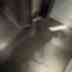

In [43]:
imgs[0].find_element(By.XPATH, ".//img").get_attribute('src')
# .get_attribute('src')

In [ ]:
copyable_attrs = r.find_element(By.XPATH, ".//div[contains(@class, 'copyable-text')]").get_attribute('data-pre-plain-text').strip()[1:-1].split('] ')

['3:29 AM, 1/6/2025', 'Shantanu UvA']

In [ ]:
copyable_scrape={}

In [ ]:
copyable_scrape['sender'] = copyable_attrs[1]
copyable_scrape['datetime'] = copyable_attrs[0]
# parse_datetime(
#         f"{copyable_attrs[0].split(', ')[1]} {copyable_attrs[0].split(', ')[0]}")

In [ ]:
copyable_scrape['message'] = r.find_elements(By.XPATH, ".//span[contains(@class, 'selectable-text')]")


In [57]:
messages = []
messages_count = 0
last_msg_date = None
for message in t:
    copyable_scrape={'message': None, 'sender': None, 'datetime': None, 'recalled_msg': False, 'has_images': False}
    messages_count += 1
    print(messages_count)
    msg_text = message.find_elements(By.XPATH, ".//span[contains(@class, 'selectable-text')]")
    if msg_text:
        copyable_scrape['message'] = msg_text[0].text
    
        temp = message.find_element(By.XPATH, ".//div[contains(@class, 'copyable-text')]").get_attribute('data-pre-plain-text').strip()[1:-1].split('] ')
        copyable_scrape['sender'] = temp[1]
        copyable_scrape['datetime'] = temp[0]
    
    if message.find_elements(By.XPATH, ".//span[contains(@class, 'quoted-mention')]"):
        copyable_scrape['recalled_msg'] = True
        
    imgs = message.find_elements(By.XPATH, ".//div[contains(@aria-label, 'Open picture')]")
    if imgs:
        copyable_scrape['has_images'] = True
        # imgs[0].find_element(By.XPATH, ".//img").get_attribute('src')
    messages.append(copyable_scrape)
    
    

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44


In [58]:
messages

[{'message': 'yessir bas coffee pee raha hu',
  'sender': 'Aswin UvA AI',
  'datetime': '1:41 PM, 1/5/2025',
  'recalled_msg': True,
  'has_images': False},
 {'message': 'fir aaya',
  'sender': 'Aswin UvA AI',
  'datetime': '1:41 PM, 1/5/2025',
  'recalled_msg': False,
  'has_images': False},
 {'message': 'thoda zyada hi maal fookne ka mann karraay but we will not be smoking chat',
  'sender': 'Aswin UvA AI',
  'datetime': '1:41 PM, 1/5/2025',
  'recalled_msg': False,
  'has_images': False},
 {'message': 'Me too but we are stronger than that ',
  'sender': 'Shantanu UvA',
  'datetime': '1:43 PM, 1/5/2025',
  'recalled_msg': False,
  'has_images': False},
 {'message': 'Raat ko bhi khelte hai',
  'sender': 'Kabir UvA',
  'datetime': '3:47 PM, 1/5/2025',
  'recalled_msg': True,
  'has_images': False},
 {'message': "Okay I'll get it",
  'sender': 'Shantanu UvA',
  'datetime': '3:48 PM, 1/5/2025',
  'recalled_msg': True,
  'has_images': False},
 {'message': "We'll also plug someone's PC to 

Cleaning steps-
- Remove deleted messages

In [11]:
from openai import OpenAI

In [ ]:
summarizer_prompt=f"""
Summarize all these text messages part of an AI Masters group chat for the course '{group_name}'

Keep in mind that these messages could have important announcements, questions, or answers to questions.

Overall split the summary into the following sections:
- Announcements
- Questions and clarifications (summarize the intermediate discussion and provide the final answer. For each topic, include its title and summary in bullet points. The bullets should include detailed information.)
- General discussion
- Action items (if any)
- Important links or resources shared
- Other

"""

In [61]:
SENDER_MAPPING={}

def generate_alpha_encoding():
    temp = list(SENDER_MAPPING.values())
    if temp:
        last_element = temp[-1]
        return chr(ord(last_element) + 1)
    else:
        return 'A'
  
def encode_senders(sender):
    if sender not in SENDER_MAPPING:
        SENDER_MAPPING[sender] = generate_alpha_encoding() 
    
    return SENDER_MAPPING[sender] # 1-based index

In [8]:
import os
from dotenv import load_dotenv
load_dotenv()

OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

In [15]:
client = OpenAI(api_key=OPENAI_API_KEY)

summarizer_messages = [
        {
            "role": "developer",
            "content": summarizer_prompt
        }
    ]

In [57]:
full_chat = ""
for i in range(len(messages)):
    # messages[i]['sender'] = encode_senders(messages[i]['sender'])
    full_chat += f"{encode_senders(messages[i]['sender'])}: {messages[i]['message']}\n"

In [74]:
summarizer_messages.append({'role': 'user', 'content': full_chat})

In [75]:
summarizer_messages

[{'role': 'developer',
  'content': "\nSummarize all these text messages part of an AI Masters group chat for the course 'Carolina Macgillavrylaan'\n\nKeep in mind that these messages could have important announcements, questions, or answers to questions.\n\nOverall split the summary into the following sections:\n- Announcements\n- Questions and clarifications (summarize the intermediate discussion and provide the final answer. For each topic, include its title and summary in bullet points. The bullets should include detailed information.)\n- General discussion\n- Action items (if any)\n- Important links or resources shared\n- Other\n\n"},
 {'role': 'user',
  'content': "A: I'm not recommending it, just saying you don't have to be afraid of legal action or someone knocking your door and kick you out\nB: Air fryer and rice cooker also available for pick up\nC: Wait so it's thirty days rather than six months?\nB: Gone\nD: I think first you get the 6 months letter and then if you ignore t

In [16]:
response = client.chat.completions.create(model="gpt-4o-mini",
            messages=summarizer_messages,
            # response_format={"type": "json_object"},
            temperature=0.1)

In [17]:
json_formatted_data = response.choices[0].message.content

In [18]:
print(json_formatted_data)

Hello! Yes, that's correct. I'm here to help with any questions or information you need. What can I assist you with today?
